In [1]:
%load_ext autoreload
%autoreload 2

In [14]:
import pandas as pd
import utils as u
import numpy as np
from chroma_transformer import KeyLabelConverter
import matplotlib.pyplot as plt
from collections import Counter

# Load data

In [3]:
metadata_df = pd.read_csv("baseline_hpc/fmak_v2.csv")
actual_keys_dict = {}

for _, row in metadata_df.iterrows():
    actual_keys_dict[row['track_id']] = u.normalize_key(row['key_and_mode'])

print(f"{len(actual_keys_dict)} actual keys loaded.")

5489 actual keys loaded.


In [4]:
krumhansl_df = pd.read_csv("baseline_hpc/krumhansl_predictions_full.csv")
krumhansl_keys_dict = {}

for _, row in krumhansl_df.iterrows():
    krumhansl_keys_dict[row['track_id']] = u.normalize_key(row['predicted_key'])

print(f"{len(krumhansl_keys_dict)} Krumhansl predictions loaded.")

5489 Krumhansl predictions loaded.


In [5]:
madmom_df = pd.read_csv("baseline_hpc/madmom_predictions_full.csv")
madmom_keys_dict = {}

for _, row in madmom_df.iterrows():
    madmom_keys_dict[row['track_id']] = u.normalize_key(row['predicted_key'])

print(f"{len(madmom_keys_dict)} Madmom predictions loaded.")

5489 Madmom predictions loaded.


# Evaluate baseline methods on entire dataset

In [6]:
track_ids = list(actual_keys_dict.keys())
actual_keys = [actual_keys_dict[tid] for tid in track_ids]
krumhansl_keys = [krumhansl_keys_dict.get(tid) for tid in track_ids]
madmom_keys = [madmom_keys_dict.get(tid) for tid in track_ids]

krumhansl_metrics = u.get_metrics(krumhansl_keys, actual_keys)
madmom_metrics = u.get_metrics(madmom_keys, actual_keys)

u.print_metrics(krumhansl_metrics, "Krumhansl")
print()
u.print_metrics(madmom_metrics, "Madmom")

=== Krumhansl ===
Accuracy: 0.5360
Average Weighted Score: 0.6154
Precision (Micro): 0.5360
Precision (Macro): 0.5098
Precision (Weighted): 0.5446
Recall (Micro): 0.5360
Recall (Macro): 0.5096
Recall (Weighted): 0.5360
F1 Score (Micro): 0.5360
F1 Score (Macro): 0.5062
F1 Score (Weighted): 0.5370

=== Madmom ===
Accuracy: 0.6533
Average Weighted Score: 0.7111
Precision (Micro): 0.6533
Precision (Macro): 0.6472
Precision (Weighted): 0.6598
Recall (Micro): 0.6533
Recall (Macro): 0.6319
Recall (Weighted): 0.6533
F1 Score (Micro): 0.6533
F1 Score (Macro): 0.6351
F1 Score (Weighted): 0.6523


# Aggregate across folds to compare with Chroma Transformer

In [7]:
def get_fold_track_ids(fold_num):
    fold_df = pd.read_csv(f"chroma_transformer/folds/fold_{fold_num:02d}/test.csv")
    return fold_df['track_id'].tolist()

all_fold_track_ids = [get_fold_track_ids(fold_num) for fold_num in range(10)]
print(f"Loaded {len(all_fold_track_ids)} fold track ID lists with lengths: {[len(ids) for ids in all_fold_track_ids]}")

Loaded 10 fold track ID lists with lengths: [549, 549, 549, 549, 549, 549, 549, 549, 549, 548]


In [8]:
def get_chroma_transformer_predictions(fold_num):
    import numpy as np
    pred_file = f"chroma_transformer/predictions/fold_{fold_num:02d}_predictions.npz"
    data = np.load(pred_file)
    predictions = data['y_pred']
    keys = [KeyLabelConverter.label_to_key(pred) for pred in predictions]
    normalized_keys = [u.normalize_key(key) for key in keys]
    fold_dict = {tid: key for tid, key in zip(all_fold_track_ids[fold_num], normalized_keys)}
    return fold_dict

def get_baseline_predictions(fold_num, baseline_keys_dict):
    fold_track_ids = all_fold_track_ids[fold_num]
    pred_dict = {tid: baseline_keys_dict.get(tid) for tid in fold_track_ids}
    return pred_dict

fold_chroma_transformer_keys = [get_chroma_transformer_predictions(fold_num) for fold_num in range(10)]
fold_krumhansl_keys = [get_baseline_predictions(fold_num, krumhansl_keys_dict) for fold_num in range(10)]
fold_madmom_keys = [get_baseline_predictions(fold_num, madmom_keys_dict) for fold_num in range(10)]
fold_actual_keys = [get_baseline_predictions(fold_num, actual_keys_dict) for fold_num in range(10)]

In [9]:
def print_fold_aggregated_metrics(fold_predicted_keys, name):
    metrics = []

    for fold_num in range(10):
        fold_track_ids = all_fold_track_ids[fold_num]
        true_keys = [fold_actual_keys[fold_num][track_id] for track_id in fold_track_ids]
        predicted_keys = [fold_predicted_keys[fold_num][track_id] for track_id in fold_track_ids]
        fold_metrics = u.get_metrics(predicted_keys, true_keys)
        metrics.append(fold_metrics)

    print(f"=== {name} Fold-Aggregated Metrics ===")
    for metric_name in metrics[0].keys():
        mu = np.mean([fold_metrics[metric_name] for fold_metrics in metrics])
        std = np.std([fold_metrics[metric_name] for fold_metrics in metrics])
        print(f"{metric_name}: {mu:.4f} ± {std:.4f}")

print_fold_aggregated_metrics(fold_krumhansl_keys, "Krumhansl")
print()
print_fold_aggregated_metrics(fold_madmom_keys, "Madmom")
print()
print_fold_aggregated_metrics(fold_chroma_transformer_keys, "Chroma Transformer")

=== Krumhansl Fold-Aggregated Metrics ===
Accuracy: 0.5360 ± 0.0212
Average Weighted Score: 0.6154 ± 0.0198
Precision (Micro): 0.5360 ± 0.0212
Precision (Macro): 0.5077 ± 0.0244
Precision (Weighted): 0.5546 ± 0.0197
Recall (Micro): 0.5360 ± 0.0212
Recall (Macro): 0.5078 ± 0.0236
Recall (Weighted): 0.5360 ± 0.0212
F1 Score (Micro): 0.5360 ± 0.0212
F1 Score (Macro): 0.4977 ± 0.0232
F1 Score (Weighted): 0.5371 ± 0.0206

=== Madmom Fold-Aggregated Metrics ===
Accuracy: 0.6533 ± 0.0219
Average Weighted Score: 0.7111 ± 0.0192
Precision (Micro): 0.6533 ± 0.0219
Precision (Macro): 0.6455 ± 0.0186
Precision (Weighted): 0.6672 ± 0.0227
Recall (Micro): 0.6533 ± 0.0219
Recall (Macro): 0.6347 ± 0.0245
Recall (Weighted): 0.6533 ± 0.0219
F1 Score (Micro): 0.6533 ± 0.0219
F1 Score (Macro): 0.6294 ± 0.0205
F1 Score (Weighted): 0.6518 ± 0.0221

=== Chroma Transformer Fold-Aggregated Metrics ===
Accuracy: 0.6316 ± 0.0271
Average Weighted Score: 0.6919 ± 0.0240
Precision (Micro): 0.6316 ± 0.0271
Precision

# Key Distance

In [10]:
# Treat chroma transformer folds as a single set of predictions across entire dataset
chroma_transformer_keys_dict = {}

for fold_num in range(10):
    fold_keys = fold_chroma_transformer_keys[fold_num]
    chroma_transformer_keys_dict.update(fold_keys)

chroma_transformer_keys = [chroma_transformer_keys_dict[tid] for tid in track_ids]

In [11]:
krumhansl_key_distances = [u.get_key_distance(pred, actual) for pred, actual in zip(krumhansl_keys, actual_keys)]
madmom_key_distances = [u.get_key_distance(pred, actual) for pred, actual in zip(madmom_keys, actual_keys)]
chroma_transformer_key_distances = [u.get_key_distance(pred, actual) for pred, actual in zip(chroma_transformer_keys, actual_keys)]

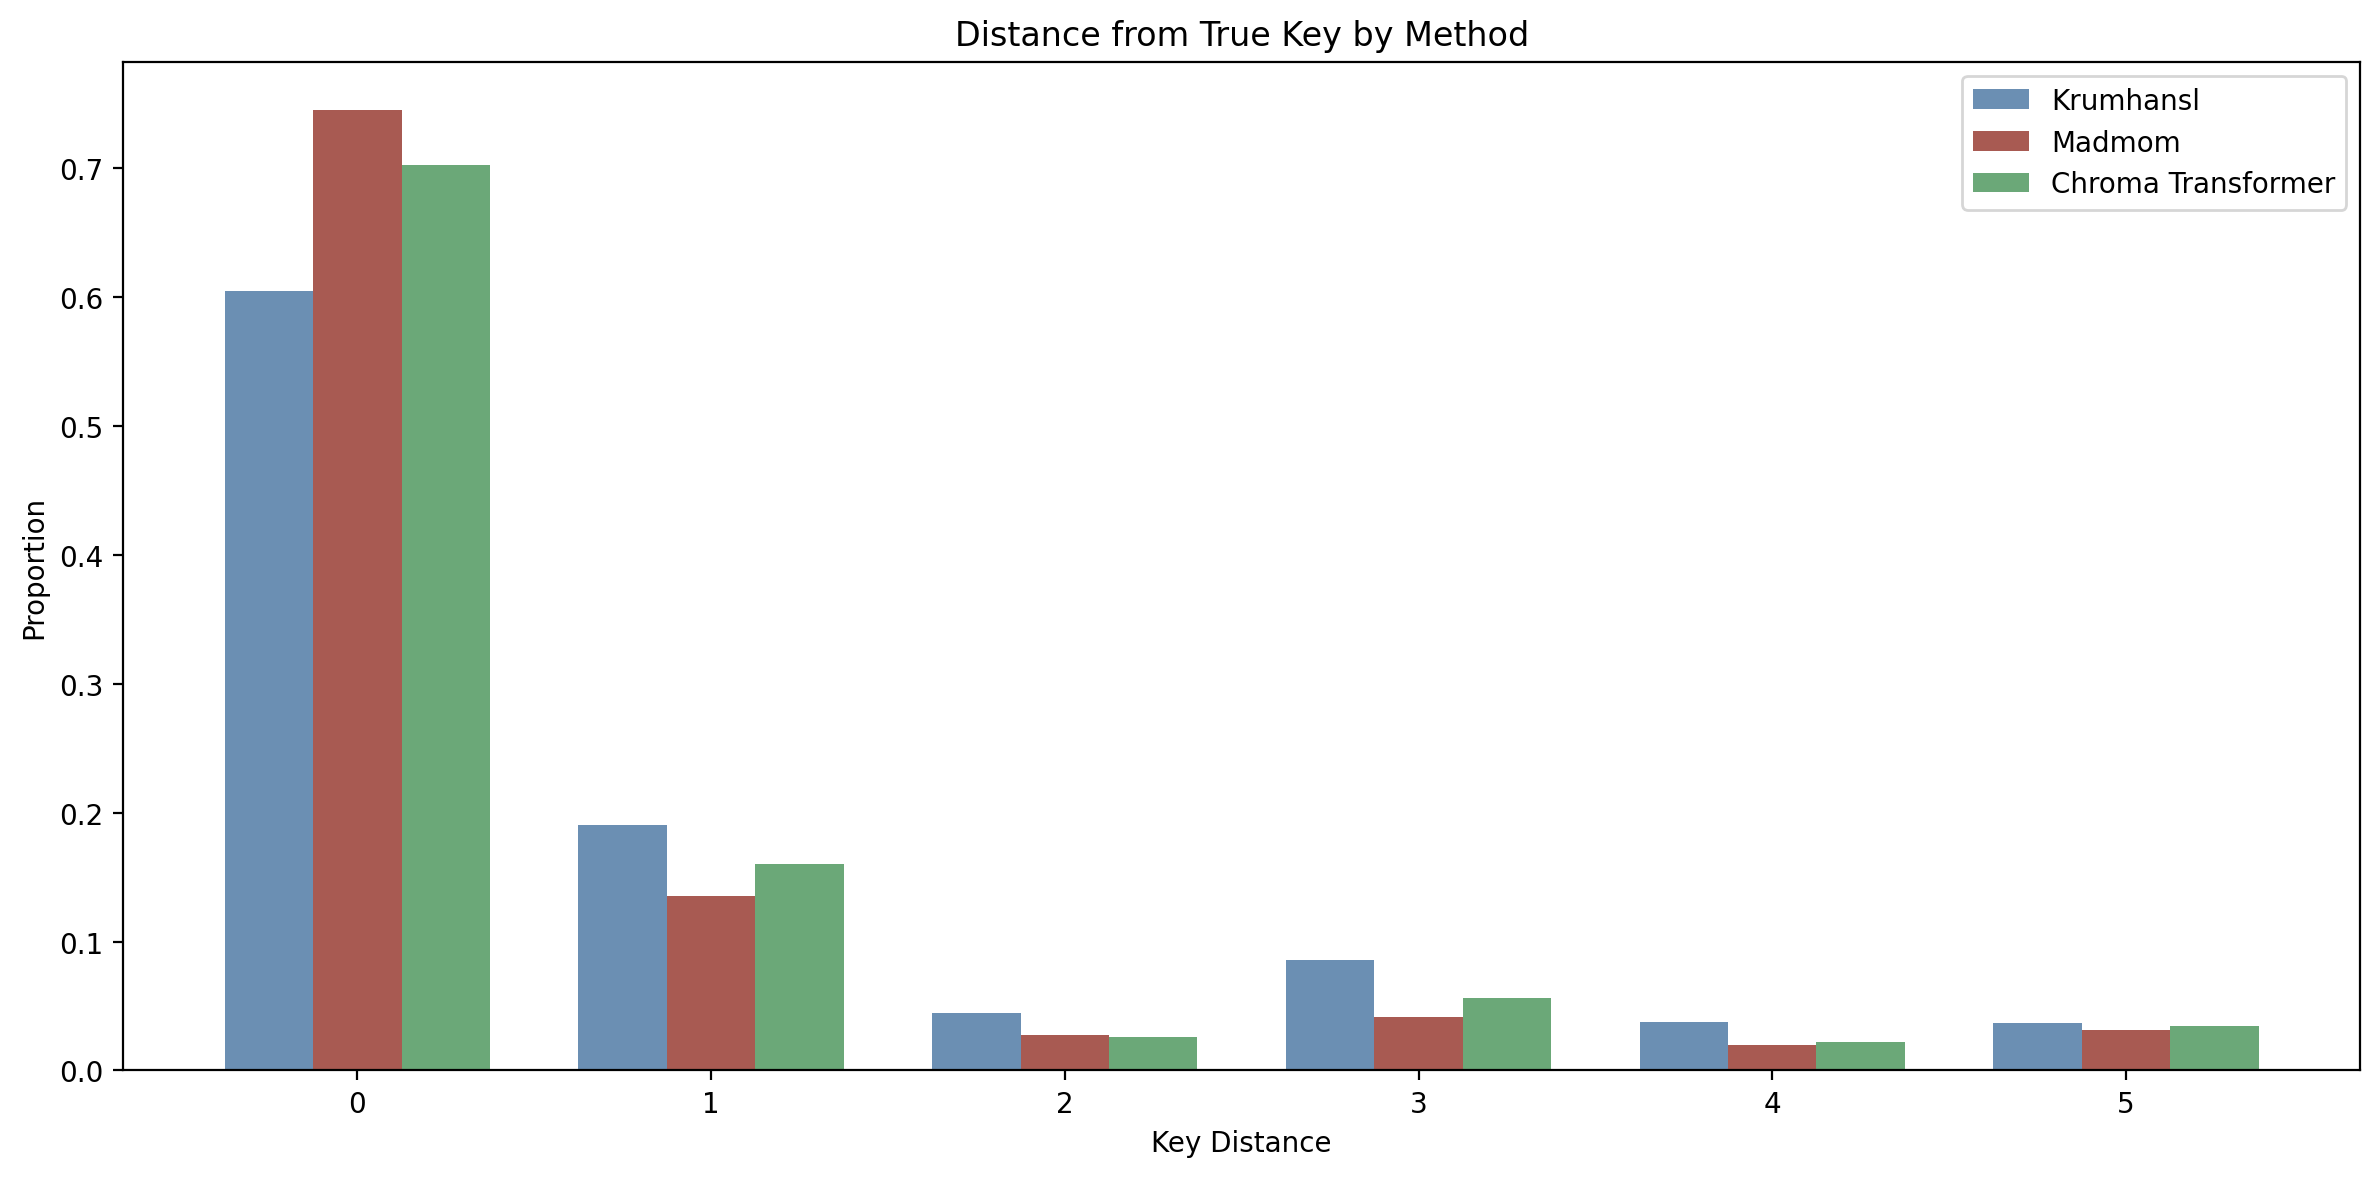

In [20]:


# Calculate key distance distributions
krumhansl_dist_counter = Counter(krumhansl_key_distances)
madmom_dist_counter = Counter(madmom_key_distances)
chroma_transformer_dist_counter = Counter(chroma_transformer_key_distances)

# Get all unique distances sorted
all_distances = sorted(set(krumhansl_key_distances) | set(madmom_key_distances) | set(chroma_transformer_key_distances))

# Convert to proportions
total = len(krumhansl_key_distances)
krumhansl_proportions = [krumhansl_dist_counter.get(d, 0) / total for d in all_distances]
madmom_proportions = [madmom_dist_counter.get(d, 0) / total for d in all_distances]
chroma_transformer_proportions = [chroma_transformer_dist_counter.get(d, 0) / total for d in all_distances]

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(all_distances))
width = 0.25

ax.bar(x - width, krumhansl_proportions, width, label='Krumhansl', color='#6b8fb3')
ax.bar(x, madmom_proportions, width, label='Madmom', color='#a85a52')
ax.bar(x + width, chroma_transformer_proportions, width, label='Chroma Transformer', color='#6ba878')

ax.set_xlabel('Key Distance')
ax.set_ylabel('Proportion')
ax.set_title('Distance from True Key by Method')
ax.set_xticks(x)
ax.set_xticklabels(all_distances)
ax.legend()

plt.tight_layout()
plt.show()

In [27]:
print("== Krumhansl ==")
print(f"Relative Key Error Proportion: {u.get_relative_key_error_proportion(krumhansl_keys, actual_keys):.4f}")
print(f"Parallel Key Error Proportion: {u.get_parallel_key_error_proportion(krumhansl_keys, actual_keys):.4f}")
print()
print("== Madmom ==")
print(f"Relative Key Error Proportion: {u.get_relative_key_error_proportion(madmom_keys, actual_keys):.4f}")
print(f"Parallel Key Error Proportion: {u.get_parallel_key_error_proportion(madmom_keys, actual_keys):.4f}")
print()
print("== Chroma Transformer ==")
print(f"Relative Key Error Proportion: {u.get_relative_key_error_proportion(chroma_transformer_keys, actual_keys):.4f}")
print(f"Parallel Key Error Proportion: {u.get_parallel_key_error_proportion(chroma_transformer_keys, actual_keys):.4f}")

== Krumhansl ==
Relative Key Error Proportion: 0.0687
Parallel Key Error Proportion: 0.0703

== Madmom ==
Relative Key Error Proportion: 0.0918
Parallel Key Error Proportion: 0.0301

== Chroma Transformer ==
Relative Key Error Proportion: 0.0707
Parallel Key Error Proportion: 0.0463
